1. Initialize the grid with input data: canopy, fuel type, fuel density, fuel height, remaining fuel,
    moisture, temperature, elevation, slope along longitude, slope along latitude, wind along longitude,
    wind along latitude, and other wildfire-related possible inputs.

2. For each iteration:
    2.1. Loop through each cell in the grid:
        2.1.1. If the cell is currently on fire:
            2.1.1.1. Calculate the new fire intensity and remaining fuel for the cell.
            2.1.1.2. Loop through each neighboring cell:
                2.1.1.2.1. If the neighboring cell is not currently on fire and the fire intensity of the
                            current cell is greater than the ignition threshold, set the neighboring cell to be on fire.
    2.2. Check for and handle fire containment and suppression actions.
    2.3. Update the wind speed and direction for the next iteration.

3. Return the final state of the grid.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
class WildfireSimulator:
    def __init__(self, width, height, fuel_type, fuel_density, moisture, temperature, wind_speed, wind_direction, elevation, slope, land_cover):

        # inputs
        # 'width' and 'height' represent the dimensions of the 2D area
        self.width = width
        self.height = height
        # 'fuel_type' is an array of integers representing the type of fuel in each cell (e.g. 0 for forest, 1 for grassland)
        self.fuel_type = fuel_type
        # 'fuel_density' is an array of floats representing the density of the fuel in each cell
        self.fuel_density = fuel_density
        # 'moisture' is an array of floats representing the moisture content of the fuel in each cell
        self.moisture = moisture
        # 'temperature' is an array of floats representing the temperature of the air in each cell
        self.temperature = temperature
        # 'wind_speed' is an array of floats representing the wind speed in each cell
        self.wind_speed = wind_speed
        # 'wind_direction' is an array of floats representing the wind direction in each cell
        self.wind_direction = wind_direction
        # 'elevation' is an array of floats representing the elevation of each cell
        self.elevation = elevation
        # 'slope' is an array of floats representing the slope of each cell
        self.slope = slope
        # 'land_cover' is an array of integers representing the land cover in each cell (e.g. 0 for forest, 1 for grassland)
        self.land_cover = land_cover

        # outputs
        self.fuel_remaining = self.calculate_fuel_remaining()
        self.remaining_fuel = np.zeros((height, width))
        self.fire_intensity = np.zeros((height, width))
        self.absorbed_heat_flux = np.zeros((height, width))
        self.fire_perimeter = np.zeros((height, width))
        self.fire_spread_rate = np.zeros((height, width))
        self.fire_line_intensity = np.zeros((height, width))
        self.fire_line_length = np.zeros((height, width))
        self.fire_behavior = np.zeros((height, width))
        self.emissions = np.zeros((height, width))
        self.grid = np.zeros((1, height, width))

        self.time = 0
        self.day_night = None
        self.weather_forecast = None
        self.human_actions = None

    def calculate_fuel_remaining_forest(fuel_density, moisture):
        # code to calculate remaining fuel for forest type based on density and moisture
        remaining_fuel = fuel_density * (1 - moisture/100)
        return remaining_fuel

    def calculate_fuel_remaining_grassland(fuel_density, moisture):
        # code to calculate remaining fuel for grassland type based on density and moisture
        remaining_fuel = fuel_density * (1 - moisture/150)
        return remaining_fuel

    def calculate_fuel_remaining(self):
        # code to calculate remaining fuel based on fuel type, density, and moisture
        fuel_remaining = np.zeros((self.height, self.width))
        for i in range(self.height):
            for j in range(self.width):
                if self.fuel_type[i][j] == 0:  # Forest
                    fuel_remaining[i][j] = self.calculate_fuel_remaining_forest(self.fuel_density[i][j], self.moisture[i][j])
                elif self.fuel_type[i][j] == 1:  # Grassland
                    fuel_remaining[i][j] = self.calculate_fuel_remaining_grassland(self.fuel_density[i][j], self.moisture[i][j])
                # add more elif statements for other fuel types
        return fuel_remaining

    def calculate_new_fire_intensity(self, current_fire_intensity, remaining_fuel, absorbed_heat_flux, wind_speed):
        # code to calculate new fire intensity based on current fire intensity, remaining fuel, absorbed heat flux, and wind speed
        new_fire_intensity = current_fire_intensity + (absorbed_heat_flux - (wind_speed * current_fire_intensity))
        return new_fire_intensity

    def calculate_new_remaining_fuel(self, current_remaining_fuel, current_fire_intensity):
        # code to calculate new remaining fuel based on current remaining fuel and current fire intensity
        new_remaining_fuel = current_remaining_fuel - current_fire_intensity
        return new_remaining_fuel
    
    def iterate(self):
        # code to update fire intensity, remaining fuel, absorbed heat flux, and other outputs for each cell
        new_fire_intensity = np.zeros((self.height, self.width))
        new_remaining_fuel = np.zeros((self.height, self.width))
        for i in range(self.height):
            for j in range(self.width):
                new_fire_intensity[i][j] = self.calculate_new_fire_intensity(self.fire_intensity[i][j], self.remaining_fuel[i][j], self.absorbed_heat_flux[i][j], self.wind_speed[i][j])
                new_remaining_fuel[i][j] = self.calculate_new_remaining_fuel(self.remaining_fuel[i][j], self.fire_intensity[i][j])
        self.fire_intensity = new_fire_intensity
        self.remaining_fuel = new_remaining_fuel

    def simulate(self, iterations):
        last_grid = np.zeros((1, self.height, self.width))
        # code to simulate the wildfire spread for a given number of iterations
        for i in range(iterations):
            # loop through each cell in the grid
            for row in range(self.height):
                for col in range(self.width):
                    # calculate the new fire intensity and remaining fuel for each cell
                    cell = last_grid[0, row, col]
                    if cell["on_fire"] == True:
                        absorbed_heat_flux = 0
                        # code to calculate absorbed heat flux from neighboring on fire cells
                        for r in range(row-1,row+2):
                            for c in range(col-1,col+2):
                                if (r>=0 and r<self.height) and (c>=0 and c<self.width):
                                    if last_grid[0,r,c]["on_fire"] == True:
                                        absorbed_heat_flux += last_grid[0,r,c]["fire_intensity"]
                        cell["fire_intensity"] = self.calculate_new_fire_intensity(cell["fire_intensity"], cell["remaining_fuel"], absorbed_heat_flux, cell["wind_speed"])
                        cell["remaining_fuel"] = self.calculate_new_remaining_fuel(cell["remaining_fuel"], cell["fire_intensity"])
                    # check if the fire has spread to neighboring cells
                    for r in range(row-1,row+2):
                        for c in range(col-1,col+2):
                            if (r>=0 and r<self.height) and (c>=0 and c<self.width):
                                if last_grid[0,r,c]["on_fire"] == False and cell["fire_intensity"] > self.ignition_threshold:
                                    last_grid[0,r,c]["on_fire"] = True
        np.append(self.grid, last_grid, axis=0)
        return self.grid

In [4]:
# size of the grid and iterations
width = 8
height = 5
iters = 2

# 'fuel_type' is an array of integers representing the type of fuel in each cell (e.g. 0 for forest, 1 for grassland)
fuel_type = np.random.randint(0, 3, (width, height))
# 'fuel_density' is an array of floats representing the density of the fuel in each cell
fuel_density = np.random.randint(0, 3, (width, height))
# 'moisture' is an array of floats representing the moisture content of the fuel in each cell
moisture = np.random.rand(width, height) * 100
# 'temperature' is an array of floats representing the temperature of the air in each cell
temperature = np.random.randint(0, 3, (width, height))
# 'wind_speed' is an array of floats representing the wind speed in each cell
wind_speed = np.random.randint(0, 3, (width, height))
# 'wind_direction' is an array of floats representing the wind direction in each cell
wind_direction = np.random.randint(0, 3, (width, height))
# 'elevation' is an array of floats representing the elevation of each cell
elevation = np.random.randint(0, 3, (width, height))
# 'slope' is an array of floats representing the slope of each cell
slope = np.random.randint(0, 3, (width, height))
# 'land_cover' is an array of integers representing the land cover in each cell (e.g. 0 for forest, 1 for grassland)
land_cover = np.random.randint(0, 3, (width, height))

# outputs
fuel_remaining = np.ones((iters, height, width))
remaining_fuel = np.zeros((iters, height, width))
fire_intensity = np.zeros((iters, height, width))
absorbed_heat_flux = np.zeros((iters, height, width))
fire_perimeter = np.zeros((iters, height, width))
fire_spread_rate = np.zeros((iters, height, width))
fire_line_intensity = np.zeros((iters, height, width))
fire_line_length = np.zeros((iters, height, width))
fire_behavior = np.zeros((iters, height, width))
emissions = np.zeros((iters, height, width))


<Figure size 1000x1000 with 0 Axes>

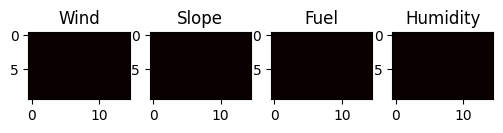

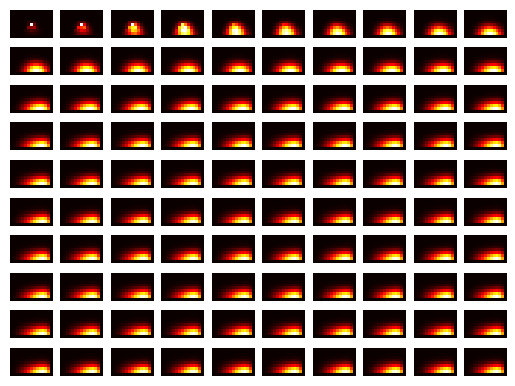

In [18]:
fig = plt.figure(figsize=(10,10))

# Define the grid size and time step
nx, ny = 10, 15
dx, dy = 2.0, 2.0
dt = 0.5

# Define the diffusion rate function
def diffusion(C, i, j, dt, dx):
    return dt * (
        (C[i+1, j] + C[i-1, j] + C[i, j+1] + C[i, j-1] + 1.41 * (C[i+1, j+1] + C[i-1, j-1] + C[i-1, j+1] + C[i+1, j-1])) +
        # (C[i+2, j] + C[i-2, j] + C[i, j+2] + C[i, j-2])/2 +
        # (C[i+3, j] + C[i-3, j] + C[i, j+3] + C[i, j-3])/3 +
        # (C[i+4, j] + C[i-4, j] + C[i, j+4] + C[i, j-4])/4 +
        - 8*C[i, j]
        ) / (dx*dx)

# Define the reaction rate function
def reaction(C, i, j, k, dt, wind, slope, fuel, humidity):
    wind_factor = 0
    slope_factor = -10
    fuel_factor = 0
    humidity_factor = 0
    return - dt * k[i, j] * C[i, j] * (1 + wind[i, j] * wind_factor + slope[i, j] * slope_factor + fuel[i, j] * fuel_factor + humidity[i, j] * humidity_factor)

# Initialize the grid
C = np.zeros((nx, ny))
C[nx//2, ny//2] = 1.0

# Input layers
k = np.ones((nx, ny)) * .8
wind = np.zeros((nx, ny))
wind_direction = np.zeros((nx, ny))
slope = np.zeros((nx, ny))
fuel = np.zeros((nx, ny))
humidity = np.zeros((nx, ny))

k[3,3] = .9

# Assign similar-to-real values to each input
for i in range(nx):
    for j in range(ny):
        wind[i, j] = 1
        slope[i, j] = 1
        fuel[i, j] = 1
        humidity[i, j] = 1

# Visualize each input
fig, axs = plt.subplots(1, 4, figsize=(6, 2))
axs = axs.ravel()
axs[0].imshow(wind, cmap='hot', interpolation='nearest')
axs[0].set_title('Wind')
axs[1].imshow(slope, cmap='hot', interpolation='nearest')
axs[1].set_title('Slope')
axs[2].imshow(fuel, cmap='hot', interpolation='nearest')
axs[2].set_title('Fuel')
axs[3].imshow(humidity, cmap='hot', interpolation='nearest')
axs[3].set_title('Humidity')
plt.show()

# Time loop
for t in range(100):
    # Spatial loop
    for i in range(1, nx-1):
        for j in range(1, ny-1):
            C[i, j] = \

            # C[i, j] = C[i, j] + diffusion(C, i, j, dt, dx) + reaction(C, i, j, k, dt, wind, slope, fuel, humidity)

    # Plot the intensity
    intensity = C
    plt.subplot(10, 10, t+1)
    plt.imshow(intensity, cmap='hot', interpolation='nearest')
    plt.axis('off')

plt.show()